In [1]:
import os

enmap_path = "../data/raw/enmap"

for root, dirs, files in os.walk(enmap_path):
    print(root)
    
    for f in files[:10]:
        print("   ", f)

../data/raw/enmap
    .gitkeep


In [2]:
pip install rasterio

   ---------------------------------------- 0.0/30.1 MB ? eta -:--:--
   -- ------------------------------------- 1.8/30.1 MB 18.3 MB/s eta 0:00:02
   ----------- ---------------------------- 8.9/30.1 MB 35.2 MB/s eta 0:00:01
   -------------- ------------------------- 10.7/30.1 MB 20.4 MB/s eta 0:00:01
   ---------------- ----------------------- 12.3/30.1 MB 16.8 MB/s eta 0:00:02
   ----------------- ---------------------- 13.4/30.1 MB 14.2 MB/s eta 0:00:02
   ------------------ --------------------- 14.2/30.1 MB 12.5 MB/s eta 0:00:02
   -------------------- ------------------- 15.2/30.1 MB 11.2 MB/s eta 0:00:02
   --------------------- ------------------ 16.3/30.1 MB 10.5 MB/s eta 0:00:02
   ---------------------- ----------------- 17.3/30.1 MB 9.8 MB/s eta 0:00:02
   ------------------------ --------------- 18.6/30.1 MB 9.4 MB/s eta 0:00:02
   -------------------------- ------------- 19.9/30.1 MB 9.2 MB/s eta 0:00:02
   ---------------------------- ----------- 21.5/30.1 MB 8.8 MB/s 


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os

print(os.getcwd())

e:\Geomind\notebooks


In [7]:
import os

print(os.listdir("../data/raw/enmap"))

['.gitkeep', 'ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-METADATA.XML', 'ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-SPECTRAL_IMAGE_COG.tiff', 'Indian_pines.mat', 'Indian_pines_gt.mat', 'Pavia.mat', 'PaviaU.mat', 'PaviaU_gt.mat', 'Pavia_gt.mat', 'Salinas.mat', 'SalinasA.mat', 'SalinasA_gt.mat', 'Salinas_gt.mat']


In [8]:
import rasterio
import numpy as np

cube_path = "../data/raw/enmap/ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-SPECTRAL_IMAGE_COG.tiff"

with rasterio.open(cube_path) as src:
    cube = src.read()

print("Cube Shape:", cube.shape)
print("Data Type:", cube.dtype)
print("Number of Bands:", cube.shape[0])
print("Height:", cube.shape[1])
print("Width:", cube.shape[2])

Cube Shape: (224, 1174, 1241)
Data Type: int16
Number of Bands: 224
Height: 1174
Width: 1241


In [9]:
import rasterio

cube_path = "../data/raw/enmap/ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-SPECTRAL_IMAGE_COG.tiff"

with rasterio.open(cube_path) as src:

    print(src.profile)

{'driver': 'GTiff', 'dtype': 'int16', 'nodata': -32768.0, 'width': 1241, 'height': 1174, 'count': 224, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 10N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32610"]]'), 'transform': Affine(30.0, 0.0, 755865.0,
       0.0, -30.0, 3830205.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'zstd', 'interleave': 'pixel'}


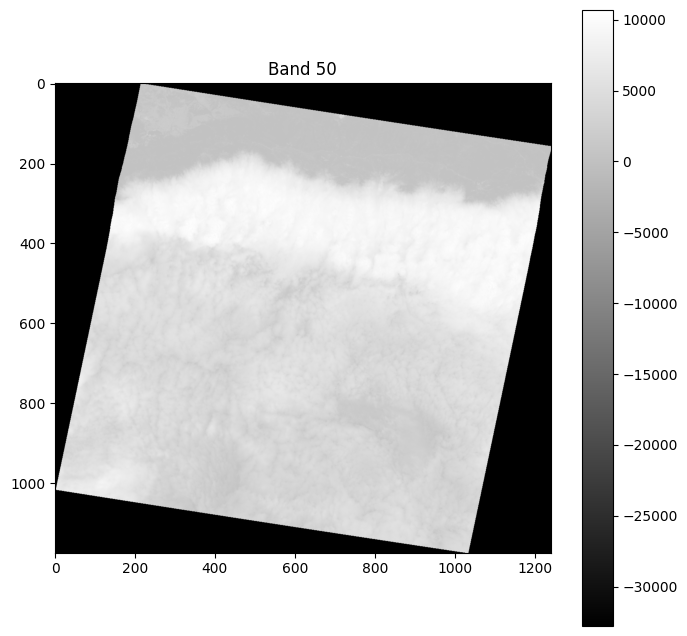

In [10]:
import matplotlib.pyplot as plt

band = cube[50]

plt.figure(figsize=(8,8))
plt.imshow(band, cmap="gray")
plt.title("Band 50")
plt.colorbar()
plt.show()

In [11]:
import xml.etree.ElementTree as ET

xml_file = "../data/raw/enmap/ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-METADATA.XML"

tree = ET.parse(xml_file)
root = tree.getroot()

print(root.tag)

for child in root[:20]:
    print(child.tag)

level_X
metadata
processing
base
specific
product


In [12]:
import xml.etree.ElementTree as ET

xml_file = "../data/raw/enmap/ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-METADATA.XML"

tree = ET.parse(xml_file)
root = tree.getroot()

for child in root:
    print(child.tag)

metadata
processing
base
specific
product


In [13]:
for child in root:
    print("\n", child.tag)

    for subchild in child[:10]:
        print("   ", subchild.tag)


 metadata
    schema
    name
    comment
    copyright
    citation

 processing
    terrainCorrection
    ozoneValue
    season
    waterReflectanceProduct
    productFormat
    mapProjection
    imageResampling
    DEMDBVersion
    correctionType
    cirrusHazeRemoval

 base
    spatialCoverage
    temporalCoverage
    revision
    altitudeCoverage
    sphere
    format
    level
    size
    archivedVersion

 specific
    spatialCoverageOfDatatake
    qualityFlag
    instrumentStatus
    productQuality
    vnirProductQuality
    swirProductQuality
    downlink
    auxDataVersion
    inputDatatake
    missionPhase

 product
    image
    quicklook
    calibration
    matching
    navigation
    time
    ortho
    smileCorrection
    productFileInformation
    bandStatistics


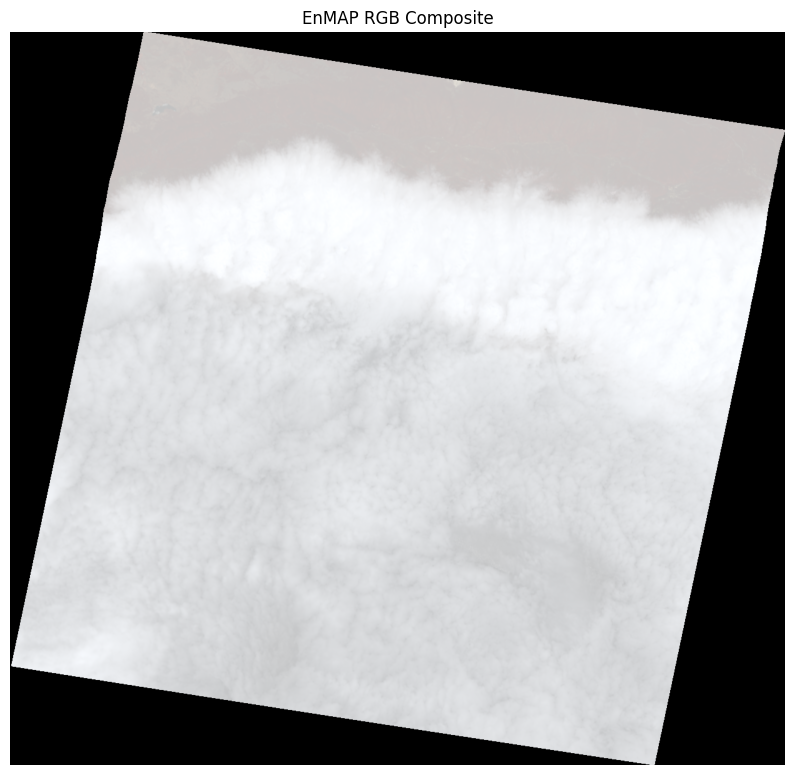

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# approximate VNIR bands
red = cube[55]
green = cube[35]
blue = cube[15]

rgb = np.dstack([red, green, blue])

# remove nodata influence
rgb = rgb.astype(np.float32)

p2 = np.percentile(rgb, 2)
p98 = np.percentile(rgb, 98)

rgb = np.clip((rgb - p2) / (p98 - p2), 0, 1)

plt.figure(figsize=(10,10))
plt.imshow(rgb)
plt.title("EnMAP RGB Composite")
plt.axis("off")
plt.show()

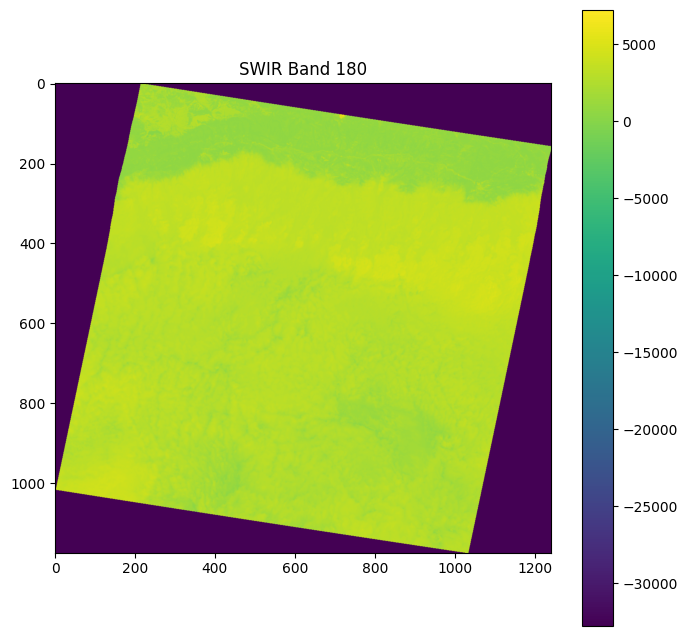

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# SWIR band (good for cloud discrimination)
band = cube[180]

plt.figure(figsize=(8,8))
plt.imshow(band)
plt.colorbar()
plt.title("SWIR Band 180")
plt.show()

In [16]:
for section in root.iter():
    if "wavelength" in section.tag.lower():
        print(section.tag, section.text)

wavelengthCenterOfBand 418.416
wavelengthCenterOfBand 424.043
wavelengthCenterOfBand 429.457
wavelengthCenterOfBand 434.686
wavelengthCenterOfBand 439.757
wavelengthCenterOfBand 444.699
wavelengthCenterOfBand 449.539
wavelengthCenterOfBand 454.306
wavelengthCenterOfBand 459.031
wavelengthCenterOfBand 463.73
wavelengthCenterOfBand 468.411
wavelengthCenterOfBand 473.08
wavelengthCenterOfBand 477.744
wavelengthCenterOfBand 482.411
wavelengthCenterOfBand 487.087
wavelengthCenterOfBand 491.78
wavelengthCenterOfBand 496.497
wavelengthCenterOfBand 501.243
wavelengthCenterOfBand 506.02
wavelengthCenterOfBand 510.828
wavelengthCenterOfBand 515.672
wavelengthCenterOfBand 520.55
wavelengthCenterOfBand 525.467
wavelengthCenterOfBand 530.424
wavelengthCenterOfBand 535.422
wavelengthCenterOfBand 540.463
wavelengthCenterOfBand 545.551
wavelengthCenterOfBand 550.687
wavelengthCenterOfBand 555.873
wavelengthCenterOfBand 561.112
wavelengthCenterOfBand 566.405
wavelengthCenterOfBand 571.756
wavelengthCen

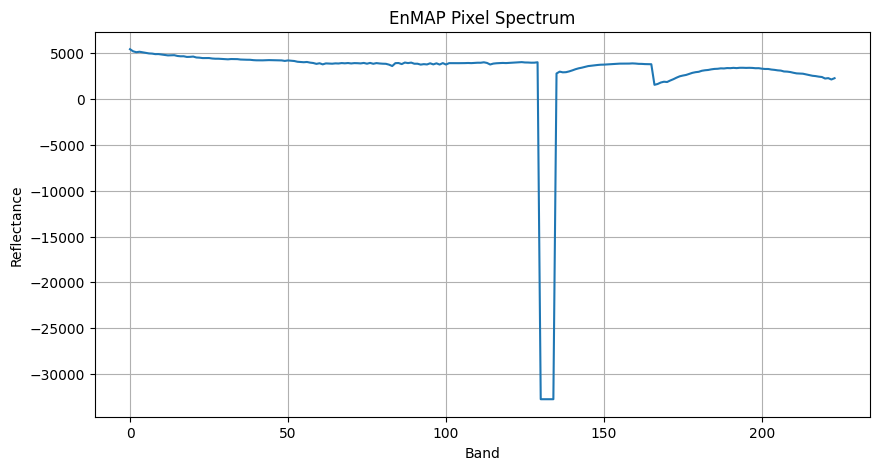

Spectrum length: 224


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# center pixel
row = cube.shape[1] // 2
col = cube.shape[2] // 2

spectrum = cube[:, row, col]

plt.figure(figsize=(10,5))
plt.plot(spectrum)
plt.title("EnMAP Pixel Spectrum")
plt.xlabel("Band")
plt.ylabel("Reflectance")
plt.grid(True)
plt.show()

print("Spectrum length:", len(spectrum))

In [18]:
import numpy as np

valid_mask = spectrum != -32768

clean_spectrum = spectrum[valid_mask]

print("Original bands:", len(spectrum))
print("Valid bands:", len(clean_spectrum))

Original bands: 224
Valid bands: 219


In [21]:
import xml.etree.ElementTree as ET

xml_file = "../data/raw/enmap/ENMAP01-____L2A-DT0000196102_20260602T192751Z_004_V010506_20260603T090712Z-METADATA.XML"

tree = ET.parse(xml_file)
root = tree.getroot()

wavelengths = []

for elem in root.iter():
    if "wavelengthCenterOfBand" in elem.tag:
        try:
            wavelengths.append(float(elem.text))
        except:
            pass

print("Number of wavelengths:", len(wavelengths))
print("First 5:", wavelengths[:5])
print("Last 5:", wavelengths[-5:])

Number of wavelengths: 224
First 5: [418.416, 424.043, 429.457, 434.686, 439.757]
Last 5: [2415.21, 2422.78, 2430.32, 2437.83, 2445.3]


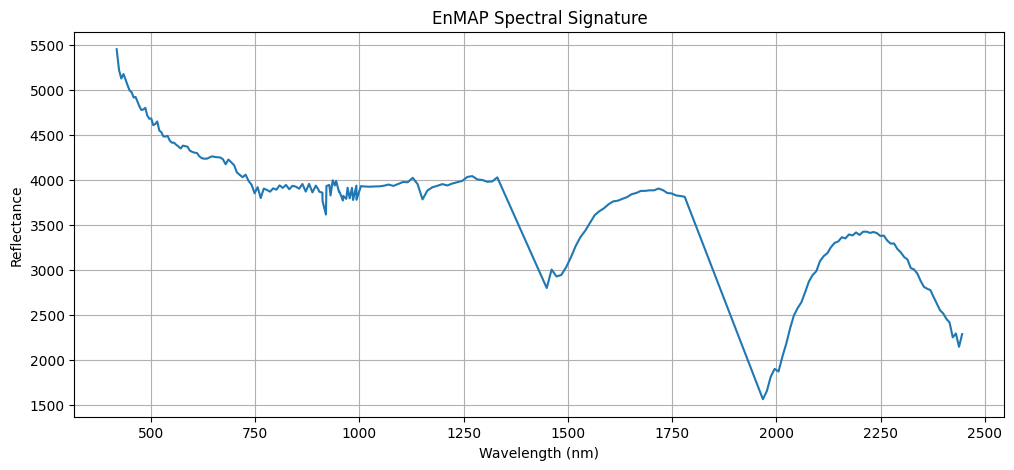

In [22]:
valid_mask = spectrum != -32768

plt.figure(figsize=(12,5))

plt.plot(
    np.array(wavelengths)[valid_mask],
    spectrum[valid_mask]
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("EnMAP Spectral Signature")
plt.grid(True)

plt.show()

In [29]:
row = 1000
col = 500

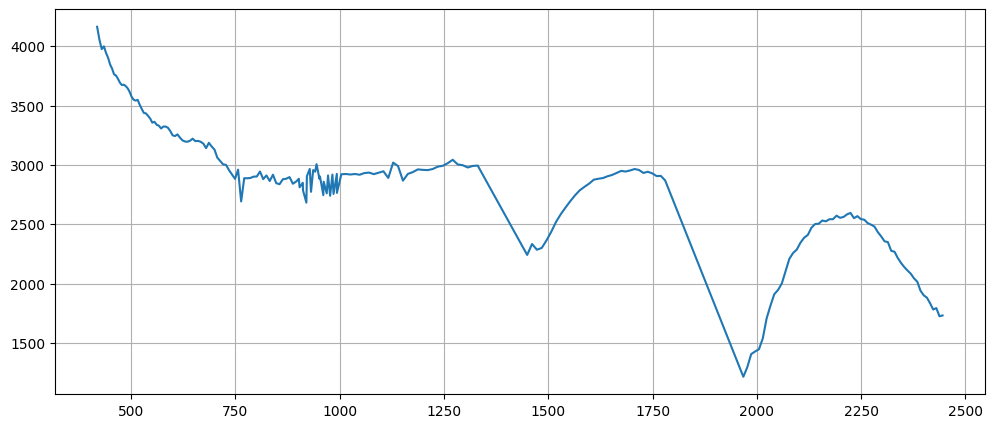

In [30]:
spectrum = cube[:, row, col]

valid_mask = spectrum != -32768

plt.figure(figsize=(12,5))
plt.plot(
    np.array(wavelengths)[valid_mask],
    spectrum[valid_mask]
)
plt.grid()
plt.show()

In [31]:
from rasterio.transform import xy

row = 950
col = 700

x, y = xy(src.transform, row, col)

print("UTM X:", x)
print("UTM Y:", y)

UTM X: 776880.0
UTM Y: 3801690.0


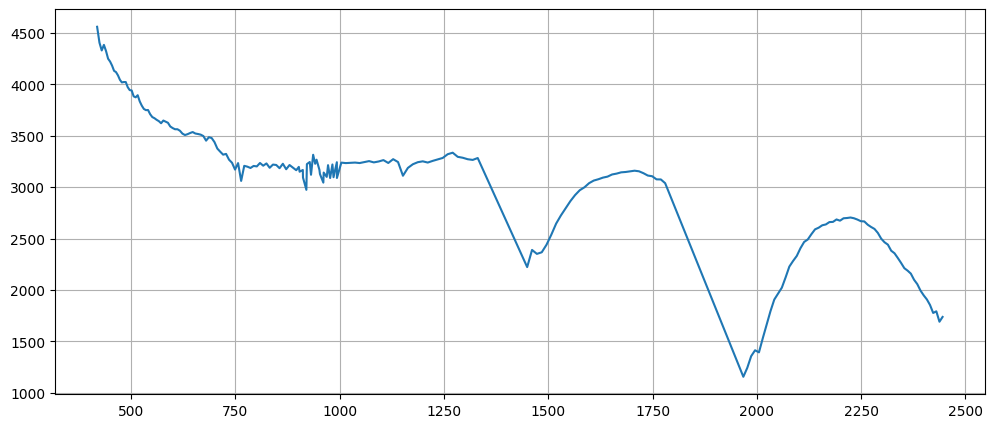

In [32]:
rows = slice(850, 1000)
cols = slice(600, 800)

roi = cube[:, rows, cols]

mean_spectrum = np.mean(
    np.where(roi == -32768, np.nan, roi),
    axis=(1,2)
)

valid = ~np.isnan(mean_spectrum)

plt.figure(figsize=(12,5))
plt.plot(
    np.array(wavelengths)[valid],
    mean_spectrum[valid]
)
plt.grid()
plt.show()

Red band: 46 660.207
NIR band: 72 847.847


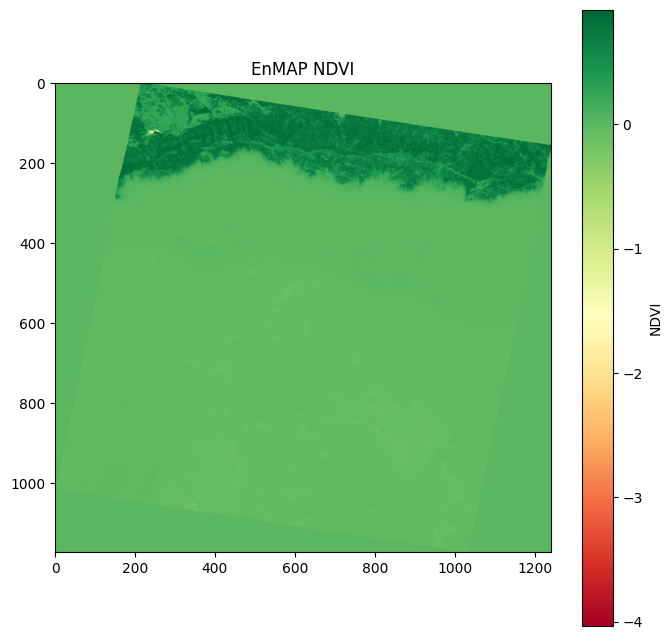

In [33]:
# Find nearest EnMAP bands

red_band = np.argmin(np.abs(np.array(wavelengths) - 660))
nir_band = np.argmin(np.abs(np.array(wavelengths) - 850))

print("Red band:", red_band, wavelengths[red_band])
print("NIR band:", nir_band, wavelengths[nir_band])

red = cube[red_band].astype(float)
nir = cube[nir_band].astype(float)

ndvi = (nir - red) / (nir + red + 1e-10)

plt.figure(figsize=(8,8))
plt.imshow(ndvi, cmap="RdYlGn")
plt.colorbar(label="NDVI")
plt.title("EnMAP NDVI")
plt.show()

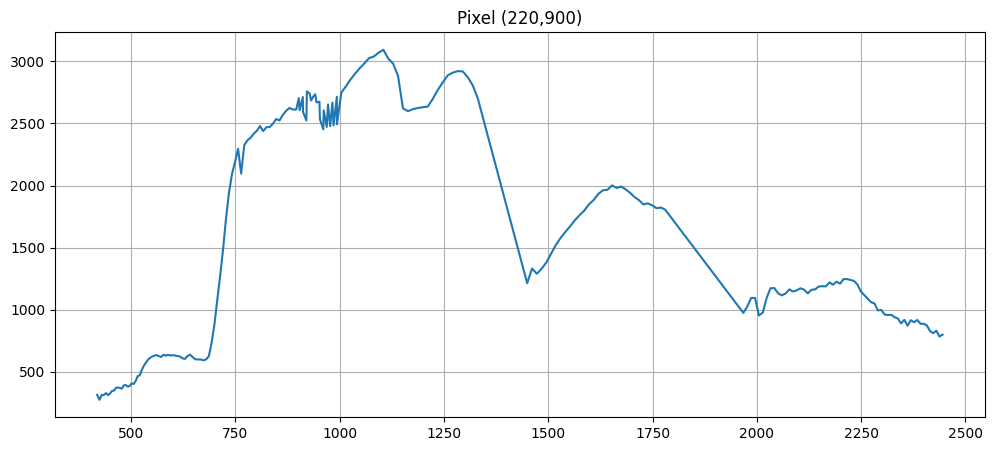

In [37]:
row = 220
col = 900

spectrum = cube[:, row, col]

valid = spectrum != -32768

plt.figure(figsize=(12,5))
plt.plot(
    np.array(wavelengths)[valid],
    spectrum[valid]
)
plt.title(f"Pixel ({row},{col})")
plt.grid()
plt.show()